# EDA — CSIC 2010

**Dataset:** HTTP CSIC 2010 — Web Attack Detection  
**Objetivo:** Entender la estructura del dataset, resolver el problema del label, y definir las features para el Modelo A.  
**Archivo:** `data/raw/csic2010/csic_database.csv`

Ver `docs/eda.md` para el plan completo de análisis.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

DATA_PATH = '../../data/raw/csic2010/csic_database.csv'

## 1. Carga y estructura básica

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (61065, 17)


,Unnamed: 0,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,cookie,content-type,connection,lenght,content,classification,URL
0,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=1F767F17239C9B670A39E9B10C3825F4,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/index.jsp HTTP/1.1
1,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=81761ACA043B0E6014CA42A4BCD06AB5,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/anadir.jsp?id=3&nombre=Vino+Rioja&prec...
2,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=933185092E0B668B90676E0A2B0767AF,application/x-www-form-urlencoded,Connection: close,Content-Length: 68,id=3&nombre=Vino+Rioja&precio=100&cantidad=55&B1=A%F1adir+al+carrito,0,http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1


In [17]:
df.dtypes

Unnamed: 0              object
Method                  object
User-Agent              object
Pragma                  object
Cache-Control           object
Accept                  object
Accept-encoding         object
Accept-charset          object
language                object
host                    object
cookie                  object
content-type            object
connection              object
lenght                  object
content                 object
label                    int64
URL                     object
url_length               int64
url_has_sq               int64
url_has_dquote           int64
url_has_lt               int64
url_has_gt               int64
url_has_sc               int64
url_has_dashdash         int64
url_has_select           int64
url_has_union            int64
url_has_script           int64
url_has_pct27            int64
url_has_pct3c            int64
content_filled          object
content_has_sq           int64
content_has_dquote       int64
content_

## 2. Descripción de columnas

| Columna | Qué es | Útil para el modelo |
|---|---|---|
| `Unnamed: 0` | Índice original con texto Normal/Anomalous | No — redundante con `classification` |
| `Method` | Método HTTP: GET o POST | Sí — feature categórica |
| `User-Agent` | Identificador del browser/cliente | Posible — ataques pueden tener UAs genéricos |
| `Pragma` | Header de caché HTTP | Probablemente no — poca variación |
| `Cache-Control` | Control de caché | Probablemente no |
| `Accept` | Tipos de contenido aceptados | Posible |
| `Accept-encoding` | Encodings aceptados | Probablemente no |
| `Accept-charset` | Charsets aceptados | Probablemente no |
| `language` | Idioma aceptado | Probablemente no |
| `host` | Host destino | No — constante (siempre localhost:8080) |
| `cookie` | Cookie de sesión JSESSIONID | Posible — presencia/ausencia |
| `content-type` | Tipo del body (NaN en GETs) | Sí — correlaciona con Method |
| `connection` | Tipo de conexión HTTP | Probablemente no |
| `lenght` | Content-Length del body (NaN en GETs) | Sí — longitud del body |
| `content` | **Body del request** — payload real | **Muy importante** — ataques POST |
| `classification` | **Label: 0=normal, 1=attack** | Target |
| `URL` | URL completa del request | **Muy importante** — ataques GET |

**Nota:** Los ataques viven principalmente en dos lugares:
- `URL` → ataques GET (SQLi, XSS en query string)
- `content` → ataques POST (SQLi, XSS en body)

## 3. El label

**Descubrimiento:** `classification` ya está en 0/1 — no necesita mapping.  
`Unnamed: 0` tiene el texto Normal/Anomalous pero es redundante.

In [4]:
print('classification — valores únicos:', df['classification'].unique())
print('Unnamed: 0 — valores únicos:', df['Unnamed: 0'].unique())
print()
print('Distribución del label:')
print(df['classification'].value_counts())

classification — valores únicos: [0 1]
Unnamed: 0 — valores únicos: ['Normal' 'Anomalous']

Distribución del label:
classification
0    36000
1    25065
Name: count, dtype: int64


In [5]:
# Renombrar para claridad
df = df.rename(columns={'classification': 'label'})
print('Label listo:', df['label'].dtype, '— valores:', df['label'].unique())

Label listo: int64 — valores: [0 1]


## 4. Distribución de clases

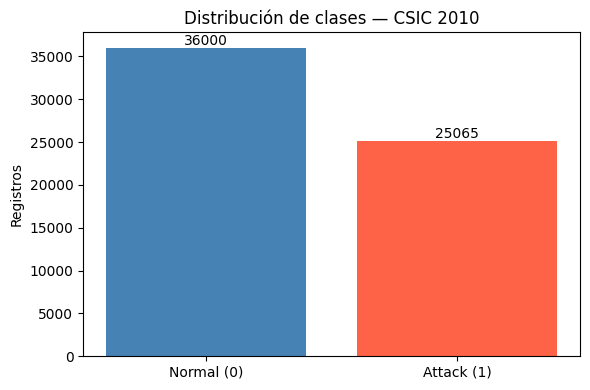

Normal: 36000 (59.0%)
Attack: 25065 (41.0%)


In [6]:
counts = df['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal (0)', 'Attack (1)'], counts.values, color=['steelblue', 'tomato'])
ax.bar_label(bars, fmt='%d')
ax.set_title('Distribución de clases — CSIC 2010')
ax.set_ylabel('Registros')
plt.tight_layout()
plt.show()

print(f'Normal: {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Attack: {counts[1]} ({counts[1]/len(df)*100:.1f}%)')

## 5. Nulos por columna

In [14]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(2)
result = pd.DataFrame({'nulos': nulls, 'pct': nulls_pct})
print('Columnas con nulos:')
print(result[nulls > 0])
print()
print('Nota: content y lenght son NaN en requests GET — esperado, no es un problema.')

Columnas con nulos:
              nulos    pct
content-type  43088  70.56
content       43088  70.56
lenght        43088  70.56
Accept          397   0.65

Nota: content y lenght son NaN en requests GET — esperado, no es un problema.


## 6. Columnas constantes o de baja variación

In [8]:
uniqueness = df.nunique().sort_values()
print('Valores únicos por columna:')
print(uniqueness)
print()
print('Columnas con 1 solo valor (constantes — descartar):')
print(uniqueness[uniqueness == 1].index.tolist())

Valores únicos por columna:
language               1
User-Agent             1
Pragma                 1
Cache-Control          1
Accept                 1
Accept-encoding        1
Accept-charset         1
content-type           1
connection             2
Unnamed: 0             2
label                  2
host                   2
Method                 3
lenght               382
content            12091
URL                13498
cookie             61065
dtype: int64

Columnas con 1 solo valor (constantes — descartar):
['language', 'User-Agent', 'Pragma', 'Cache-Control', 'Accept', 'Accept-encoding', 'Accept-charset', 'content-type']


In [9]:
print('Distribución de Method (GET/POST):')
print(df['Method'].value_counts())
print()
print('Method por clase:')
print(pd.crosstab(df['Method'], df['label']))

Distribución de Method (GET/POST):
Method
GET     43088
POST    17580
PUT       397
Name: count, dtype: int64

Method por clase:
label       0      1
Method              
GET     28000  15088
POST     8000   9580
PUT         0    397


## 7. Feature engineering — URL

URL length por clase:
         count   mean   std   min   25%   50%    75%    max
label                                                      
0      36000.0   79.0  59.4  48.0  57.0  58.5   67.0  367.0
1      25065.0  106.6  91.6  31.0  57.0  64.0  122.0  895.0


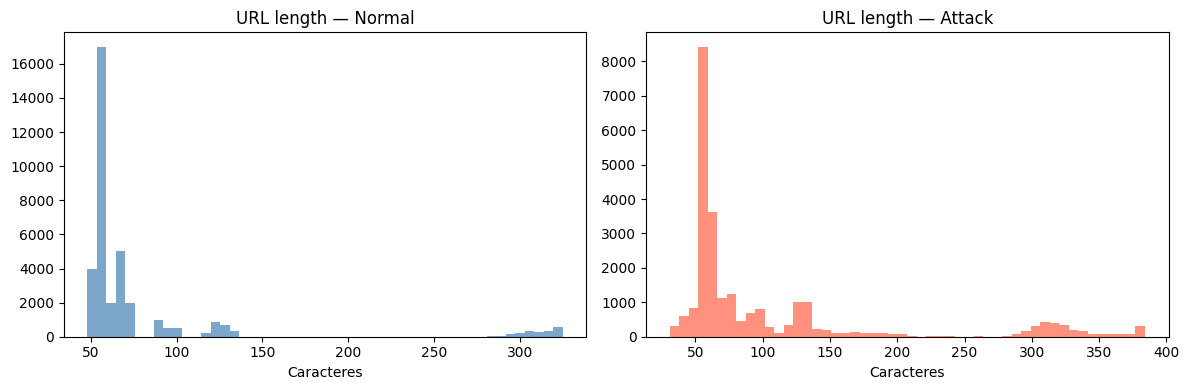

In [10]:
# Longitud de URL
df['url_length'] = df['URL'].str.len()

print('URL length por clase:')
print(df.groupby('label')['url_length'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lbl, color in zip(axes, [0, 1], ['steelblue', 'tomato']):
    subset = df[df['label'] == lbl]['url_length']
    ax.hist(subset.clip(upper=subset.quantile(0.99)), bins=50, color=color, alpha=0.7)
    ax.set_title(f'URL length — {"Normal" if lbl == 0 else "Attack"}')
    ax.set_xlabel('Caracteres')
plt.tight_layout()
plt.show()

In [11]:
# Indicadores de ataque en URL
indicators = {
    'sq': "'",
    'dquote': '"',
    'lt': '<',
    'gt': '>',
    'sc': ';',
    'dashdash': '--',
    'select': 'SELECT',
    'union': 'UNION',
    'script': 'script',
    'pct27': '%27',
    'pct3c': '%3C'
}

for name, ind in indicators.items():
    df[f'url_has_{name}'] = df['URL'].str.contains(ind, case=False, regex=False).astype(int)

feature_cols = [c for c in df.columns if c.startswith('url_has_')]
corr = df[feature_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print('Correlación indicadores URL con label:')
print(corr.round(3))

Correlación indicadores URL con label:
url_has_pct27       0.183
url_has_dashdash    0.148
url_has_script      0.137
url_has_pct3c       0.124
url_has_select      0.050
url_has_union      -0.003
url_has_sq            NaN
url_has_dquote        NaN
url_has_lt            NaN
url_has_gt            NaN
url_has_sc            NaN
Name: label, dtype: float64


## 8. Feature engineering — content (body POST)

In [12]:
# Solo requests POST tienen content
df_post = df[df['Method'] == 'POST'].copy()
print(f'Requests POST: {len(df_post)} ({len(df_post)/len(df)*100:.1f}% del total)')
print(f'Distribución label en POSTs:')
print(df_post['label'].value_counts())

# Longitud del body
df_post['content_length'] = df_post['content'].str.len().fillna(0)
print()
print('Content length por clase (solo POSTs):')
print(df_post.groupby('label')['content_length'].describe().round(1))

Requests POST: 17580 (28.8% del total)
Distribución label en POSTs:
label
1    9580
0    8000
Name: count, dtype: int64

Content length por clase (solo POSTs):
        count   mean    std  min   25%   50%    75%    max
label                                                     
0      8000.0   91.6   95.6  4.0  29.0  47.5  110.5  307.0
1      9580.0  123.2  111.5  4.0  42.0  72.0  243.0  836.0


In [13]:
# Indicadores de ataque en content
df['content_filled'] = df['content'].fillna('')

for name, ind in indicators.items():
    df[f'content_has_{name}'] = df['content_filled'].str.contains(ind, case=False, regex=False).astype(int)

content_cols = [c for c in df.columns if c.startswith('content_has_')]
corr_content = df[content_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print('Correlación indicadores content con label:')
print(corr_content.round(3))

Correlación indicadores content con label:
content_has_pct27       0.183
content_has_dashdash    0.148
content_has_script      0.126
content_has_pct3c       0.124
content_has_select      0.048
content_has_union      -0.003
content_has_sq            NaN
content_has_dquote        NaN
content_has_lt            NaN
content_has_gt            NaN
content_has_sc            NaN
Name: label, dtype: float64


## 9. Observaciones clave

### Label
- `classification` ya está en `int64` con valores `[0, 1]` — no necesita mapping
- `Unnamed: 0` tiene el texto Normal/Anomalous pero es redundante — descartar
- Columna renombrada a `label`

### Distribución de clases
- **Normal (0):** 36.000 (59%)
- **Attack (1):** 25.065 (41%)
- Desbalance leve — usar `class_weight='balanced'`, no necesita SMOTE

### Métodos HTTP
- **GET:** 43.088 — tasa de ataque 35%
- **POST:** 17.580 — tasa de ataque 54%
- **PUT:** 397 — tasa de ataque **100%** ← feature más poderosa

### Nulos
- `content`, `lenght`, `content-type`: 70.56% nulos — corresponden a GETs sin body. Esperado, no es error.
- `Accept`: 0.65% nulos — descartar la columna (es constante entre no-nulos)

### Columnas a descartar (constantes o sin señal)
- Constantes (1 único valor): `language`, `User-Agent`, `Pragma`, `Cache-Control`, `Accept`, `Accept-encoding`, `Accept-charset`, `content-type`
- Sin señal útil: `Unnamed: 0`, `host`, `connection`

### Features más prometedoras

**Method (categórica → 2 binarias):**
- `method_is_put` → correlación perfecta (100% ataques)
- `method_is_post` → tasa de ataque 54%

**URL (features de texto):**
- `url_length` → ataques tienen cola más larga, pero se solapan con normales
- `url_has_pct27` (`%27` = `'` encoded) → correlación 0.183 con label
- `url_has_dashdash` (`--`) → correlación 0.148
- `url_has_script` → correlación 0.137
- `url_has_pct3c` (`%3C` = `<` encoded) → correlación 0.124
- `url_has_select` → correlación 0.050
- **Descartadas:** chars crudos `'`, `"`, `<`, `>`, `;` → NaN (nunca aparecen literales en URLs)

**Content POST (features de texto):**
- `content_length` → ataques POST tienen body 35% más largo (media 123 vs 92 chars), cola hasta 836 chars
- Mismos indicadores de texto que URL — pendiente calcular correlaciones

### Hallazgos de seguridad
- Los atacantes usan **URL encoding** para evadir filtros — `'` → `%27`, `<` → `%3C`
- PUT es un vector de ataque claro en este dataset (File Disclosure / Path Traversal)
- POST tiene mayor tasa de ataque que GET — inyecciones por body son más comunes

### Decisiones para preprocessing
- Descartar 11 columnas constantes o redundantes
- Construir features binarias de URL-encoding (`%27`, `%3C`, etc.)
- `content_length = 0` para GETs (no NaN) — permite al modelo distinguir métodos
- Encoding de Method: one-hot en GET/POST/PUT
- No normalizar features binarias — solo `url_length` y `content_length`